In [1]:
import ccdproc
from os import listdir
from astropy.io import fits
import glob
import pylab
from astropy.table import Table
import numpy as np 
import ccdproc as cp 
from glob import glob
import matplotlib.pyplot as plt
from ccdproc import *   
import astropy.units as u
import os
from glob import glob
import glob
import math 

In [2]:
# subtract_fits_images('HIP19139-g80o50-0001-100ms.fit', 'dark-g80o50-0004-100ms.fit', 'HIP19139-g80o50-0001-100ms-subdark.fit')

In [3]:
# def takemean( path ):
#     fh=fits.open(path)     
#     return  fh[0].data[1050:1106,930:964].mean()

def takestat( path ):
    fh=fits.open(path)
     
        
    #return fh[0].header["EXPTIME"], fh[0].data[644:1140,860:1110].sum()   ### 取总和   
    return fh[0].header["EXPTIME"], fh[0].data[680:1140,890:1090].sum()   ### 取总和   要尽量大 覆盖到


    #return fh[0].header["EXPTIME"], fh[0].data[975:1114,918:995].mean()   ###取小范围    
    #return fh[0].header["EXPTIME"], fh[0].data[828:1212,886:1068].mean()    ####取适当范围（基本包括全部）


# def takevariance( path ):
#     fh=fits.open(path)
#     return  fh[0].data[1050:1106,930:964].var()/2

def takestd( path ):
    fh=fits.open(path)
    return  fh[0].data[650:1130,910:1150].std()
    
 

In [4]:
#实验
rows = []
for afile in glob.glob("155nm-0005-0d04s-subdark.fit"):
    rows.append(takestat(afile))
    print(rows)

exptime
-------
   0.01
   0.02
   0.03
      count       
------------------
274193343.20000005
 559434864.0000001
 832963755.1999999


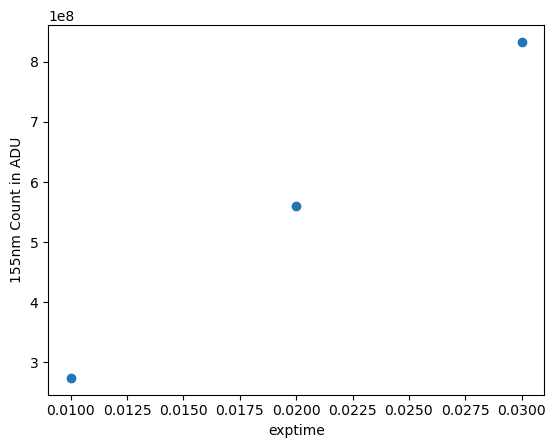

In [5]:

rows = []
for afile in glob.glob("155nm-0006*subdark.fit"):
    rows.append(takestat(afile))
table = Table(rows=rows,names=("exptime","count")) 
pylab.xlabel("exptime")
pylab.ylabel("155nm Count in ADU")
pylab.plot(table["exptime"],table["count"],"o")

print(table["exptime"])
print(table["count"])
#5.236e+09 x - 3.279e+06


RMSE= 2760693.2718954883
z1= [ 2.79385206e+10 -3.23975787e+06]
拟合后的公式是：
p1= 
2.794e+10 x - 3.24e+06± 2760693.2718954883


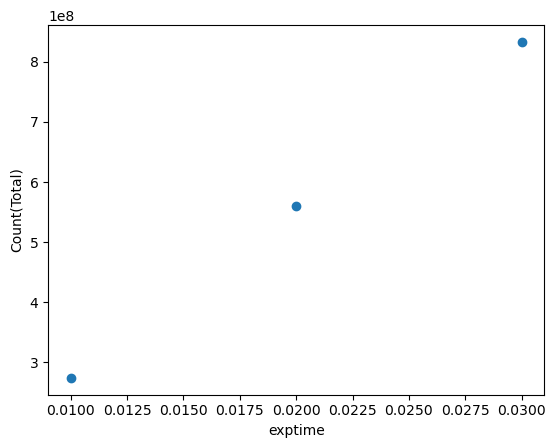

In [6]:
X = table["exptime"]
Y = table["count"]
pylab.xlabel("exptime")
pylab.ylabel("Count(Total)")
pylab.plot(X,Y,"o")

# z1 = np.polyfit(X, Y, 1)   ###线性拟合
# p1 = np.poly1d(z1)

# print('z1=',z1)
# print("拟合后的公式是：")
# print('p1=',p1)
# ##以前QE的结果是 0.2283954900010651

z1 = np.polyfit(X, Y, 1)   ###线性拟合
slope, intercept = z1
y_fit = slope * X + intercept
residuals = Y - y_fit#残差
mse = np.mean(residuals**2)#均方误差
rmse = np.sqrt(mse)#均方根误差
p1 = np.poly1d(z1)
print('RMSE=',rmse)

print('z1=',z1)
print("拟合后的公式是：")  
print("p1=%s± %s" % (p1,rmse))

In [8]:
from uncertainties import ufloat
x = ufloat(2.794e+10 - 3.24e+06, 2760693.2718954883)
print("一秒钟内的count数是",x)
gain =ufloat(0.106,0.006)
electron_num = gain * x
print("一秒钟内的电子数是")
print(f"{electron_num}")  

photo_num= ufloat(12817636486,71718631.58)

QE=electron_num / photo_num
print(QE)
# ##以前QE的结果是 0.2283954900010651

一秒钟内的count数是 (2.79368+/-0.00028)e+10
一秒钟内的电子数是
(2.96+/-0.17)e+09
0.231+/-0.013
